**Kernel:** `spatialdata`

Edit **`celltyping_config.yaml`** in this folder to change QC cutoffs, spatial crop, scanpy settings, Leiden annotations, and rule-based marker panels — then re-run from the config cell.

In [1]:
from pathlib import Path
import sys
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import spatialdata as sd
import spatialdata_plot  # registers .pl accessor
import pandas as pd
import scanpy as sc
RAW_DIR = Path("/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_04/raw_data")
sys.path.insert(0, str(RAW_DIR.parent.parent.parent / "src"))

from load_explore import setup_notebook_paths
from spatial_plot import plot_gene_seg_transcripts

setup_notebook_paths(raw_dir=RAW_DIR)

SDATA_PATH = RAW_DIR / "sdata.zarr"

assert SDATA_PATH.is_dir(), f"Missing zarr store: {SDATA_PATH}"
print(f"Zarr path: {SDATA_PATH}")

import sys
sys.path.append("/mnt/scratch2/Maycon/Utils/py_codabase")
import Utils

PROC_DIR = RAW_DIR.parent / "processed_data"
sys.path.insert(0, str(PROC_DIR))

import importlib
import celltyping_helpers
importlib.reload(celltyping_helpers)

from celltyping_helpers import (
    curate_rule_panels,
    format_curated_yaml_snippet,
    apply_spatial_crop,
    assign_rule_labels_from_panels,
    flatten_panel_markers,
    load_celltyping_config,
    panel_detection_summary,
    qc_mask_from_config,
    resolve_panel_markers,
    select_panel_markers,
    compare_rule_vs_scanpy,
    celltype_fdr,
    compare_fdr_rule_vs_scanpy,
    plot_fdr_rule_vs_scanpy,
    validate_rule_panels_align,
)

CFG = load_celltyping_config(PROC_DIR / "celltyping_config.yaml")
SCANPY_CFG = CFG["scanpy"]
CLUSTER_ANNOTATIONS = CFG["cluster_annotations"]
RULE_PANELS = CFG["rule_panels"]
RULE_CFG = CFG["rule"]
CURATION_CFG = CFG.get("curation", {})
OBS_KEYS = CFG["obs_keys"]
COMPARISON_CFG = CFG.get("comparison", {})

print(f"Config: {PROC_DIR / 'celltyping_config.yaml'}")
print(f"Rule panels: {list(RULE_PANELS.keys())}")
for msg in validate_rule_panels_align(CLUSTER_ANNOTATIONS, RULE_PANELS):
    print(f"Panel alignment warning: {msg}")


/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Zarr path: /mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_04/raw_data/sdata.zarr
Config: /mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_04/processed_data/celltyping_config.yaml
Rule panels: ['Epithelial', 'Endothelial', 'Activated endothelial', 'SPP1+ stromal', 'Fibroblast / stromal', 'SPP1+ myeloid', 'Lymphoid', 'Smooth muscle / pericyte']


In [33]:
sdata = sd.read_zarr(SDATA_PATH)
adata = sdata["table"]


print("Tables:", list(sdata.tables.keys()))
print("Shapes:", list(sdata.shapes.keys()))
print("Points:", list(sdata.points.keys()))
print("Images:", list(sdata.images.keys()) or "(none)")
print(f"\nAnnData: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
print(f"obs columns ({len(adata.obs.columns)}): {list(adata.obs.columns)[:12]} ...")
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"layers: {list(adata.layers.keys()) or '(none)'}")
print(f"Table region: {adata.uns['spatialdata_attrs']['region']}")

Tables: ['table']
Shapes: ['cell_boundaries']
Points: ['transcripts']
Images: (none)

AnnData: 260,979 cells x 6,519 genes
obs columns (81): ['RNA_nbclust_e8a1ce76.7e4f.4aa2.9ff8.a9e8a8e14460_1_clusters', 'RNA_nbclust_e8a1ce76.7e4f.4aa2.9ff8.a9e8a8e14460_1_posterior_probability', 'RNA_nbclust_0dccc116.0cc4.45ad.8d93.f913cb7fb09e_1_clusters', 'RNA_nbclust_0dccc116.0cc4.45ad.8d93.f913cb7fb09e_1_posterior_probability', 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK'] ...
obsm keys: ['spatial', 'global']
layers: (none)
Table region: cell_boundaries


In [20]:

# Sanity check: .X should hold integer raw RNA counts
x = adata.X
vals = x.data if hasattr(x, "data") else np.asarray(x).ravel()

assert vals.min() >= 0, f"Expected nonnegative counts, got min={vals.min()}"
assert np.allclose(vals, np.round(vals)), "Non-integer values in .X"

# exprMat includes Negative/SystemControl probes; compare RNA genes only to nCount_RNA
rna_mask = ~adata.var_names.str.match(r"^(Negative|SystemControl)")
row_sums = np.asarray(adata[:, rna_mask].X.sum(axis=1)).ravel()
ref = adata.obs["nCount_RNA"].to_numpy(dtype=float)
assert np.allclose(row_sums, ref, atol=5), "X row sums (RNA genes) must match obs['nCount_RNA']"

print(f"X holds integer counts (min={vals.min():.0f}, max={vals.max():.0f})")
print(f"Row-sum check vs nCount_RNA (RNA genes, atol=5): OK ({adata.n_obs:,} cells)")

X holds integer counts (min=1, max=181)
Row-sum check vs nCount_RNA (RNA genes, atol=5): OK (78,836 cells)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse


# --------------------------------------------------
# Compute QC metrics from adata.X
# --------------------------------------------------

if sparse.issparse(adata.X):
    adata.obs["nCount"] = np.asarray(adata.X.sum(axis=1)).ravel()
    adata.obs["nFeature"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()
else:
    adata.obs["nCount"] = adata.X.sum(axis=1)
    adata.obs["nFeature"] = (adata.X > 0).sum(axis=1)

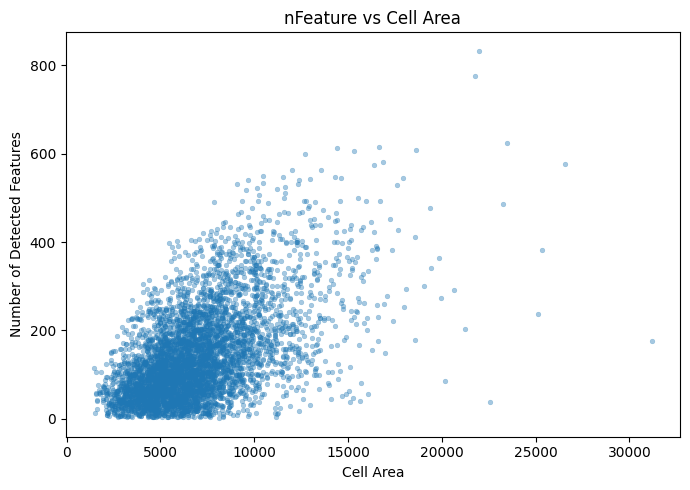

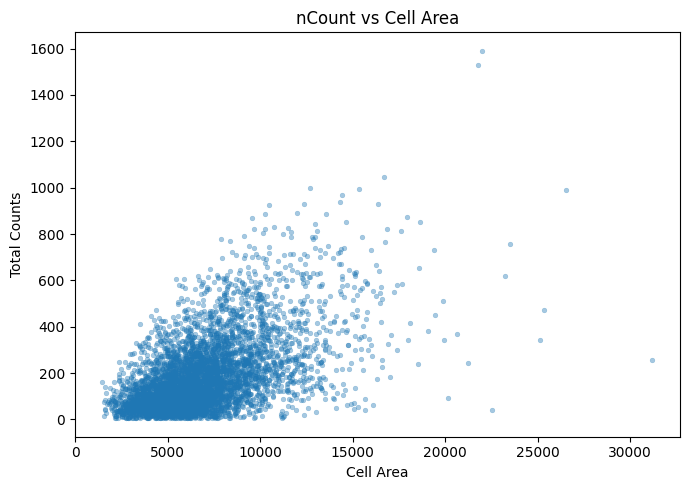

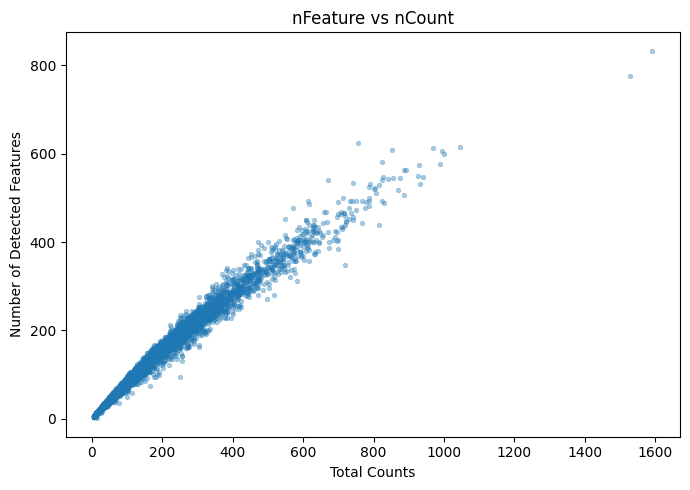

In [24]:
# Plot basic QC 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --------------------------------------------------
# Randomly sample 5,000 cells
# --------------------------------------------------

rng = np.random.default_rng(42)

n = min(5000, adata.n_obs)
idx = rng.choice(adata.n_obs, size=n, replace=False)

qc = adata.obs.iloc[idx].copy()


# Make sure Area is numeric
qc["Area"] = qc["Area"].astype(float)


# --------------------------------------------------
# 1. nFeature vs Area
# --------------------------------------------------

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=qc,
    x="Area",
    y="nFeature",
    s=12,
    alpha=0.4,
    edgecolor=None
)

plt.xlabel("Cell Area")
plt.ylabel("Number of Detected Features")
plt.title("nFeature vs Cell Area")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 2. nCount vs Area
# --------------------------------------------------

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=qc,
    x="Area",
    y="nCount",
    s=12,
    alpha=0.4,
    edgecolor=None
)

plt.xlabel("Cell Area")
plt.ylabel("Total Counts")
plt.title("nCount vs Cell Area")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. nFeature vs nCount
# --------------------------------------------------

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=qc,
    x="nCount",
    y="nFeature",
    s=12,
    alpha=0.4,
    edgecolor=None
)

plt.xlabel("Total Counts")
plt.ylabel("Number of Detected Features")
plt.title("nFeature vs nCount")
plt.tight_layout()
plt.show()

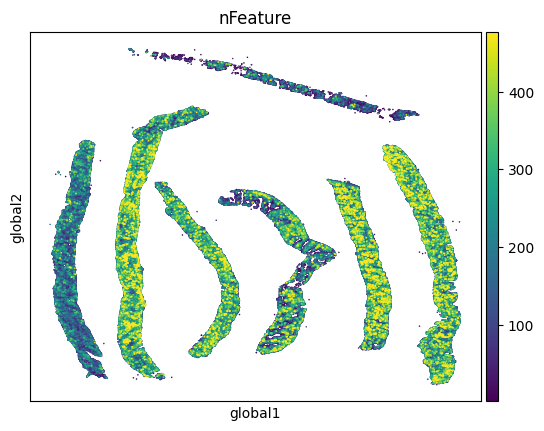

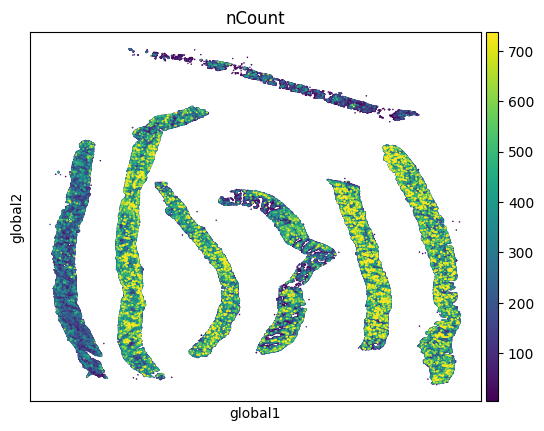

In [25]:
import scanpy as sc

# nFeature
sc.pl.embedding(
    adata,
    basis="global",
    color="nFeature",
    size=5,
    cmap="viridis",
    vmax="p99",
    title="nFeature"
)

# nCount
sc.pl.embedding(
    adata,
    basis="global",
    color="nCount",
    size=5,
    cmap="viridis",
    vmax="p99",
    title="nCount"
)

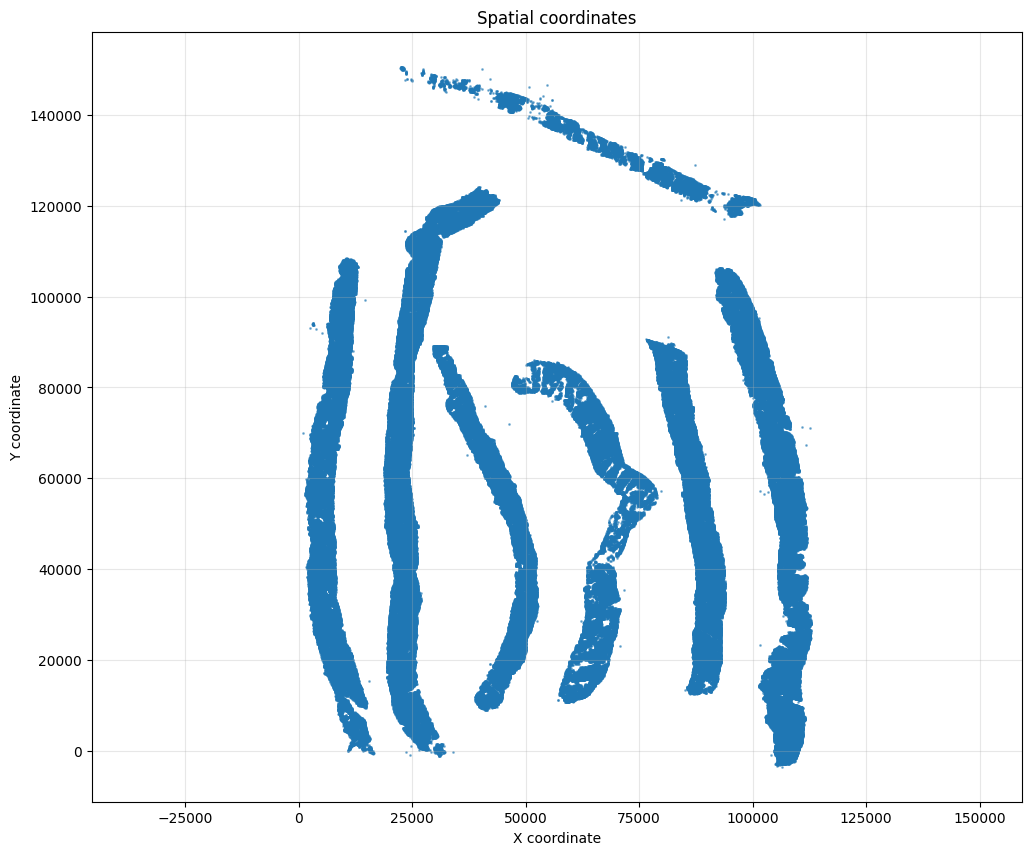

In [11]:
import matplotlib.pyplot as plt

xy = adata.obsm["global"]

plt.figure(figsize=(12, 10))

plt.scatter(
    xy[:, 0],
    xy[:, 1],
    s=1,
    alpha=0.5
)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Spatial coordinates")

plt.grid(True, alpha=0.3)
plt.axis("equal")

plt.show()

In [26]:
crop = CFG["spatial_crop"]
if crop.get("enabled", False):
    n_before = adata.n_obs
    adata = apply_spatial_crop(adata, CFG)
    print(f"Spatial crop: {n_before:,} -> {adata.n_obs:,} cells")
else:
    print("Spatial crop disabled in config")


Original: 78,836 cells
Cropped:  78,836 cells


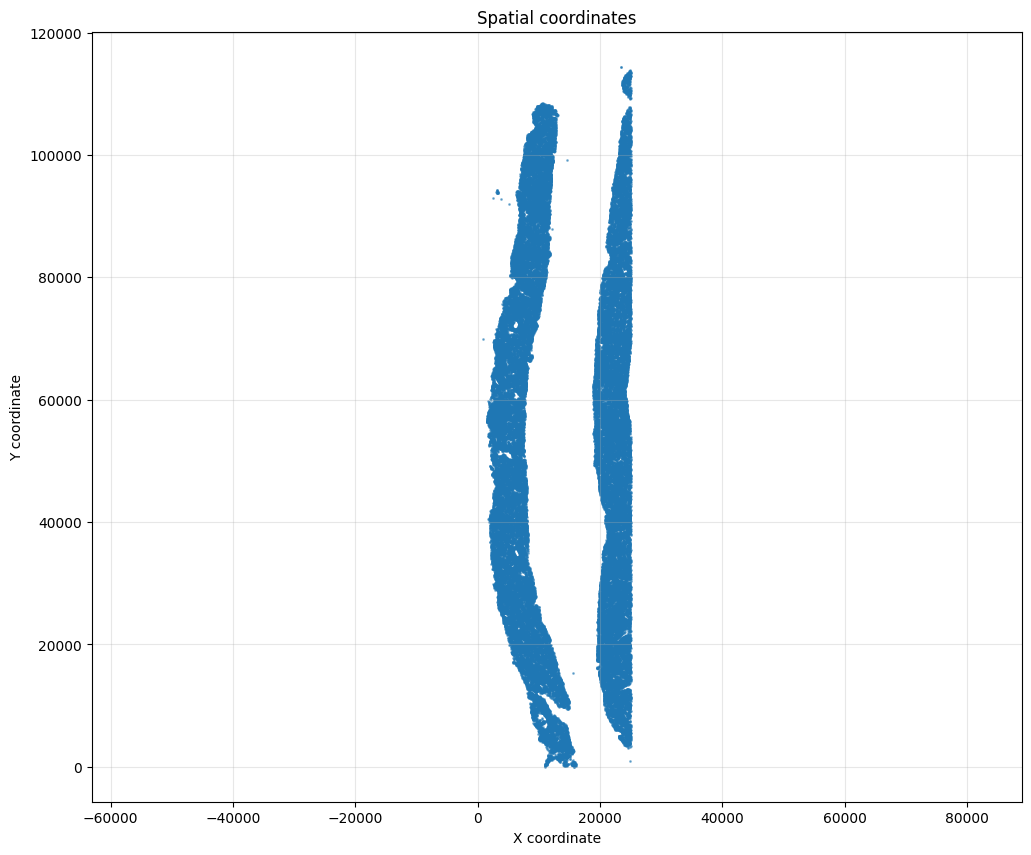

In [27]:
import matplotlib.pyplot as plt

xy = adata.obsm["global"]

plt.figure(figsize=(12, 10))

plt.scatter(
    xy[:, 0],
    xy[:, 1],
    s=1,
    alpha=0.5
)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Spatial coordinates")

plt.grid(True, alpha=0.3)
plt.axis("equal")

plt.show()

In [48]:
qc_mask = qc_mask_from_config(adata, CFG)

print(f"Total cells:     {adata.n_obs:,}")
print(f"Passed QC:       {qc_mask.sum():,}")
print(f"Failed QC:       {(~qc_mask).sum():,}")

adata_sc = adata[qc_mask].copy()


Total cells:     78,836
Passed QC:       64,325
Failed QC:       14,511


## 2. Approach i — scanpy clustering + manual annotation

Standard scanpy workflow on `adata`. After marker tables render, update `cluster_annotations` in `celltyping_config.yaml` (loaded as `CLUSTER_ANNOTATIONS`).


Total cells:  78,836
Passed QC:    64,325
Failed QC:    14,511

Clustering 64,325 cells


/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_3637702/462266118.py:125: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0' '1' '1' ... '4' '0' '4']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[adata_sc.obs_names, "leiden"] = (



QC:
passed_QC
True     64325
False    14511
Name: count, dtype: int64

Leiden:
leiden
0      16852
NaN    14511
1      13611
2       7894
3       7439
4       6542
5       5720
6       3685
7       1515
8       1067
Name: count, dtype: int64

Cells with UMAP: 64,325
Cells without UMAP: 14,511

Final adata:
AnnData object with n_obs × n_vars = 78836 × 6519
    obs: 'RNA_nbclust_e8a1ce76.7e4f.4aa2.9ff8.a9e8a8e14460_1_clusters', 'RNA_nbclust_e8a1ce76.7e4f.4aa2.9ff8.a9e8a8e14460_1_posterior_probability', 'RNA_nbclust_0dccc116.0cc4.45ad.8d93.f913cb7fb09e_1_clusters', 'RNA_nbclust_0dccc116.0cc4.45ad.8d93.f913cb7fb09e_1_posterior_probability', 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.G', 'Max.G', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'CenterX

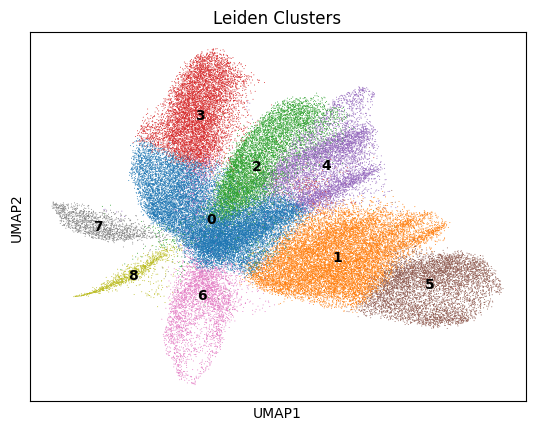

In [49]:
import numpy as np
import scanpy as sc

qc_mask = qc_mask_from_config(adata, CFG)
print(f"Total cells:  {adata.n_obs:,}")
print(f"Passed QC:    {qc_mask.sum():,}")
print(f"Failed QC:    {(~qc_mask).sum():,}")

adata_sc = adata[qc_mask].copy()
print(f"\nClustering {adata_sc.n_obs:,} cells")

sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)
sc.pp.scale(adata_sc, max_value=10)

n_comps = min(
    SCANPY_CFG["n_pcs"],
    adata_sc.n_obs - 1,
    adata_sc.n_vars - 1,
)

sc.tl.pca(adata_sc, n_comps=n_comps, random_state=SCANPY_CFG["seed"])
sc.pp.neighbors(adata_sc, n_neighbors=SCANPY_CFG["n_neighbors"], n_pcs=n_comps)
sc.tl.leiden(
    adata_sc,
    resolution=SCANPY_CFG["leiden_resolution"],
    key_added=OBS_KEYS["leiden"],
    random_state=SCANPY_CFG["seed"],
)
sc.tl.umap(adata_sc, random_state=SCANPY_CFG["seed"])

adata.obs["passed_QC"] = qc_mask
adata.obs[OBS_KEYS["leiden"]] = np.nan
adata.obs.loc[adata_sc.obs_names, OBS_KEYS["leiden"]] = adata_sc.obs[OBS_KEYS["leiden"]].astype(str)

adata.obsm["X_umap"] = np.full((adata.n_obs, 2), np.nan)
adata.obsm["X_umap"][qc_mask.to_numpy()] = adata_sc.obsm["X_umap"]

print(adata.obs[OBS_KEYS["leiden"]].value_counts(dropna=False))


In [50]:
adata_rank = adata[qc_mask].copy()
sc.pp.normalize_total(adata_rank, target_sum=1e4)
sc.pp.log1p(adata_rank)
sc.tl.rank_genes_groups(
    adata_rank,
    groupby=OBS_KEYS["leiden"],
    method="wilcoxon",
    use_raw=False,
)
adata.uns["rank_genes_groups"] = adata_rank.uns["rank_genes_groups"]


In [ ]:
# adata.write_h5ad(
#     "/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_04/processed_data/scanpy_cluster.h5ad"
# )

In [2]:
adata = ad.read_h5ad("/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_04/processed_data/scanpy_cluster.h5ad")

,cluster,names,scores,logfoldchanges,pvals,pvals_adj
0,0,A1BG,67.101295,1.969141,0.000000e+00,0.000000e+00
1,0,COX1,41.289806,1.197524,0.000000e+00,0.000000e+00
2,0,COX2,35.437325,1.106118,4.547597e-275,2.280445e-272
3,0,GPX3,33.955025,1.735037,1.028305e-252,3.724180e-250
4,0,IL22RA2,12.768873,0.952313,2.446715e-37,2.098702e-35
...,...,...,...,...,...,...
175,8,DCN,10.298571,3.389888,7.151579e-25,2.331057e-22
176,8,PTPRO,10.224003,4.723502,1.548129e-24,4.805834e-22
177,8,COL4A3,10.154027,4.214824,3.179662e-24,9.392090e-22
178,8,SPOCK2,10.149999,4.195140,3.313669e-24,9.392090e-22


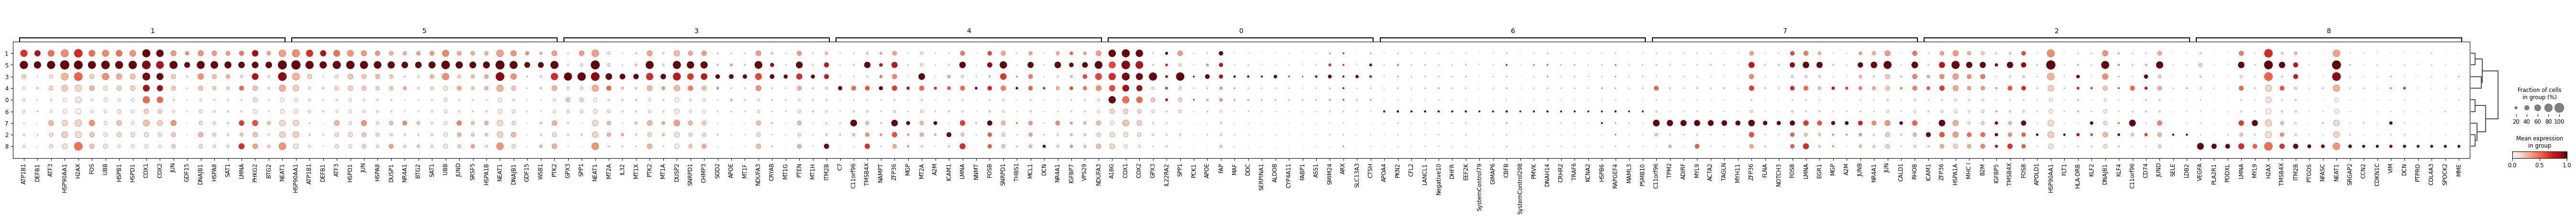

In [3]:
top_n = SCANPY_CFG["rank_genes_top_n"]
clusters = sorted(
    adata.obs[OBS_KEYS["leiden"]].dropna().unique(),
    key=lambda x: int(x),
)

marker_tables = []
for cluster in clusters:
    df = sc.get.rank_genes_groups_df(adata, group=cluster)
    df = df.head(top_n).copy()
    df.insert(0, "cluster", cluster)
    marker_tables.append(df)

markers_top = pd.concat(marker_tables, ignore_index=True)
display(markers_top)

sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=top_n,
    groupby=OBS_KEYS["leiden"],
    standard_scale="var",
    show=False,
)
plt.show()


In [4]:
marker_dict = (
    markers_top
    .groupby("cluster", sort=False)["names"]
    .apply(list)
    .to_dict()
)
marker_dict


{'0': ['A1BG',
  'COX1',
  'COX2',
  'GPX3',
  'IL22RA2',
  'SPP1',
  'PCK1',
  'APOE',
  'FAP',
  'MAF',
  'DDC',
  'SERPINA1',
  'ALDOB',
  'CYP4A11',
  'FABP1',
  'ASS1',
  'SMIM24',
  'ARX',
  'SLC13A3',
  'CTSH'],
 '1': ['ATP1B1',
  'DEFB1',
  'ATF3',
  'HSP90AA1',
  'H2AX',
  'FOS',
  'UBB',
  'HSPB1',
  'HSPD1',
  'COX1',
  'COX2',
  'JUN',
  'GDF15',
  'DNAJB1',
  'HSPA8',
  'SAT1',
  'LMNA',
  'PHKG2',
  'BTG2',
  'NEAT1'],
 '2': ['ICAM1',
  'ZFP36',
  'HSPA1A',
  'MHC I',
  'B2M',
  'IGFBP5',
  'TMSB4X',
  'FOSB',
  'APOLD1',
  'HSP90AA1',
  'FLT1',
  'HLA-DRB',
  'KLF2',
  'DNAJB1',
  'KLF4',
  'C11orf96',
  'CD74',
  'JUND',
  'SELE',
  'LDB2'],
 '3': ['GPX3',
  'SPP1',
  'NEAT1',
  'MT2A',
  'IL32',
  'MT1X',
  'PTK2',
  'MT1A',
  'DUSP2',
  'SNRPD1',
  'CHMP3',
  'SOD2',
  'APOE',
  'MT1F',
  'NDUFA3',
  'CRYAB',
  'MT1G',
  'PTEN',
  'MT1H',
  'ITM2B'],
 '4': ['C7',
  'C11orf96',
  'TMSB4X',
  'NAMPT',
  'ZFP36',
  'MGP',
  'MT2A',
  'A2M',
  'ICAM1',
  'LMNA',
  'NNMT',

In [5]:
# Edit cluster_annotations in celltyping_config.yaml, then re-run this cell.
leiden_key = OBS_KEYS["leiden"]
scanpy_key = OBS_KEYS["cell_type_scanpy"]

adata.obs[scanpy_key] = (
    adata.obs[leiden_key]
    .astype(str)
    .map(CLUSTER_ANNOTATIONS)
    .fillna(RULE_CFG["unassigned_label"])
)
adata.obs[scanpy_key] = adata.obs[scanpy_key].astype("category")
display(adata.obs[scanpy_key].value_counts(dropna=False))


cell_type_scanpy
Epithelial                  19331
SPP1+ stromal               16852
Unassigned                  14511
Activated endothelial        7894
SPP1+ myeloid                7439
Fibroblast / stromal         6542
Lymphoid                     3685
Smooth muscle / pericyte     1515
Endothelial                  1067
Name: count, dtype: int64

In [6]:
adata.obs["coord_x"] = adata.obsm["global"][:, 0]
adata.obs["coord_y"] = adata.obsm["global"][:, 1]

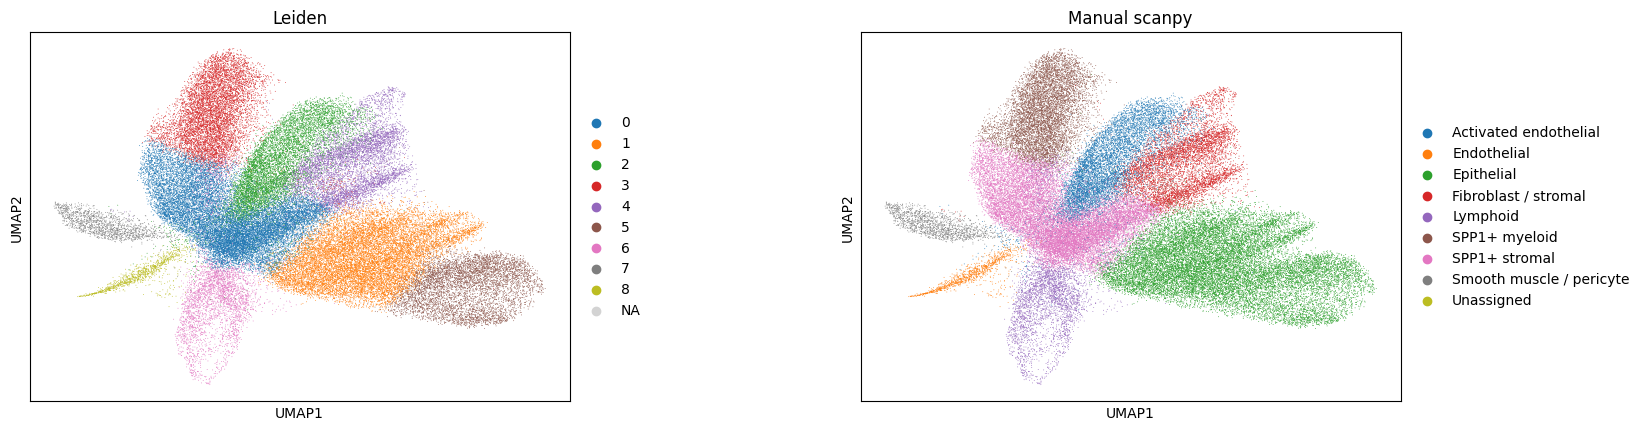

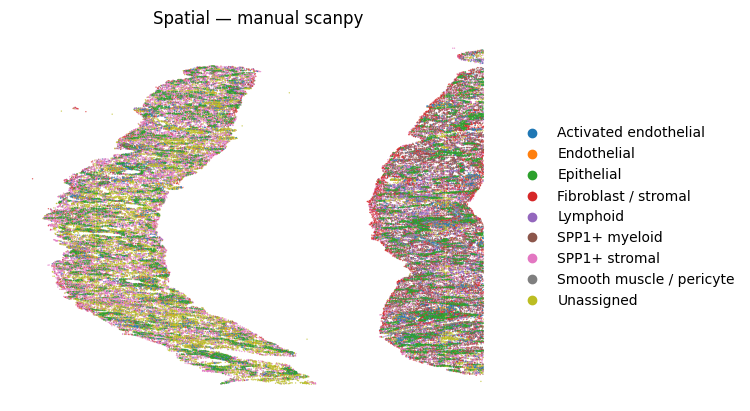

In [5]:
sc.pl.umap(
    adata,
    color=[OBS_KEYS["leiden"], OBS_KEYS["cell_type_scanpy"]],
    wspace=0.4,
    title=["Leiden", "Manual scanpy"],
)

Utils.SpatialCoord_plot(
    adata,
    variable=OBS_KEYS["cell_type_scanpy"],
    size=4,
    alpha=0.7,
    title="Spatial — manual scanpy",
)


## 3. Approach ii — rule-based typing from config panels

Panel keys in `rule_panels` must match **`cluster_annotations` / `cell_type_scanpy`** names (same labels as approach i). Each panel lists canonical human kidney marker **candidates**; §3a curation picks `markers` + `min_hits` for CosMx dropout.

### 3a. Curate panel gene sets (elbow before dropout)


### 3a. Curate panel gene sets (elbow before dropout)

Edit `candidates` in `celltyping_config.yaml`, run the cells below, review dropout curves, then paste the YAML snippet into `rule_panels` as fixed `markers` + `min_hits`.


In [7]:
CURATED = curate_rule_panels(
    adata,
    RULE_PANELS,
    {**RULE_CFG, **CURATION_CFG},
)
display(CURATED["summary_table"])


,panel,recommended_genes,min_hits,k_recommended,k_cliff,n_assigned,method,missing_genes
0,Epithelial,[EPCAM],1,1,2,5424,before_max_dropout,"[SLC34A1, CUBN]"
1,Endothelial,[ENG],1,1,2,2087,before_max_dropout,[]
2,Activated endothelial,[ICAM1],1,1,2,8687,before_max_dropout,[ESM1]
3,SPP1+ stromal,[SPP1],1,1,2,22105,before_max_dropout,[]
4,Fibroblast / stromal,[FAP],1,1,2,17090,before_max_dropout,[]
5,SPP1+ myeloid,[SPP1],1,1,2,22105,before_max_dropout,[]
6,Lymphoid,[IL7R],1,1,2,1923,before_max_dropout,[]
7,Smooth muscle / pericyte,[ACTA2],1,1,2,3157,before_max_dropout,[CNN1]


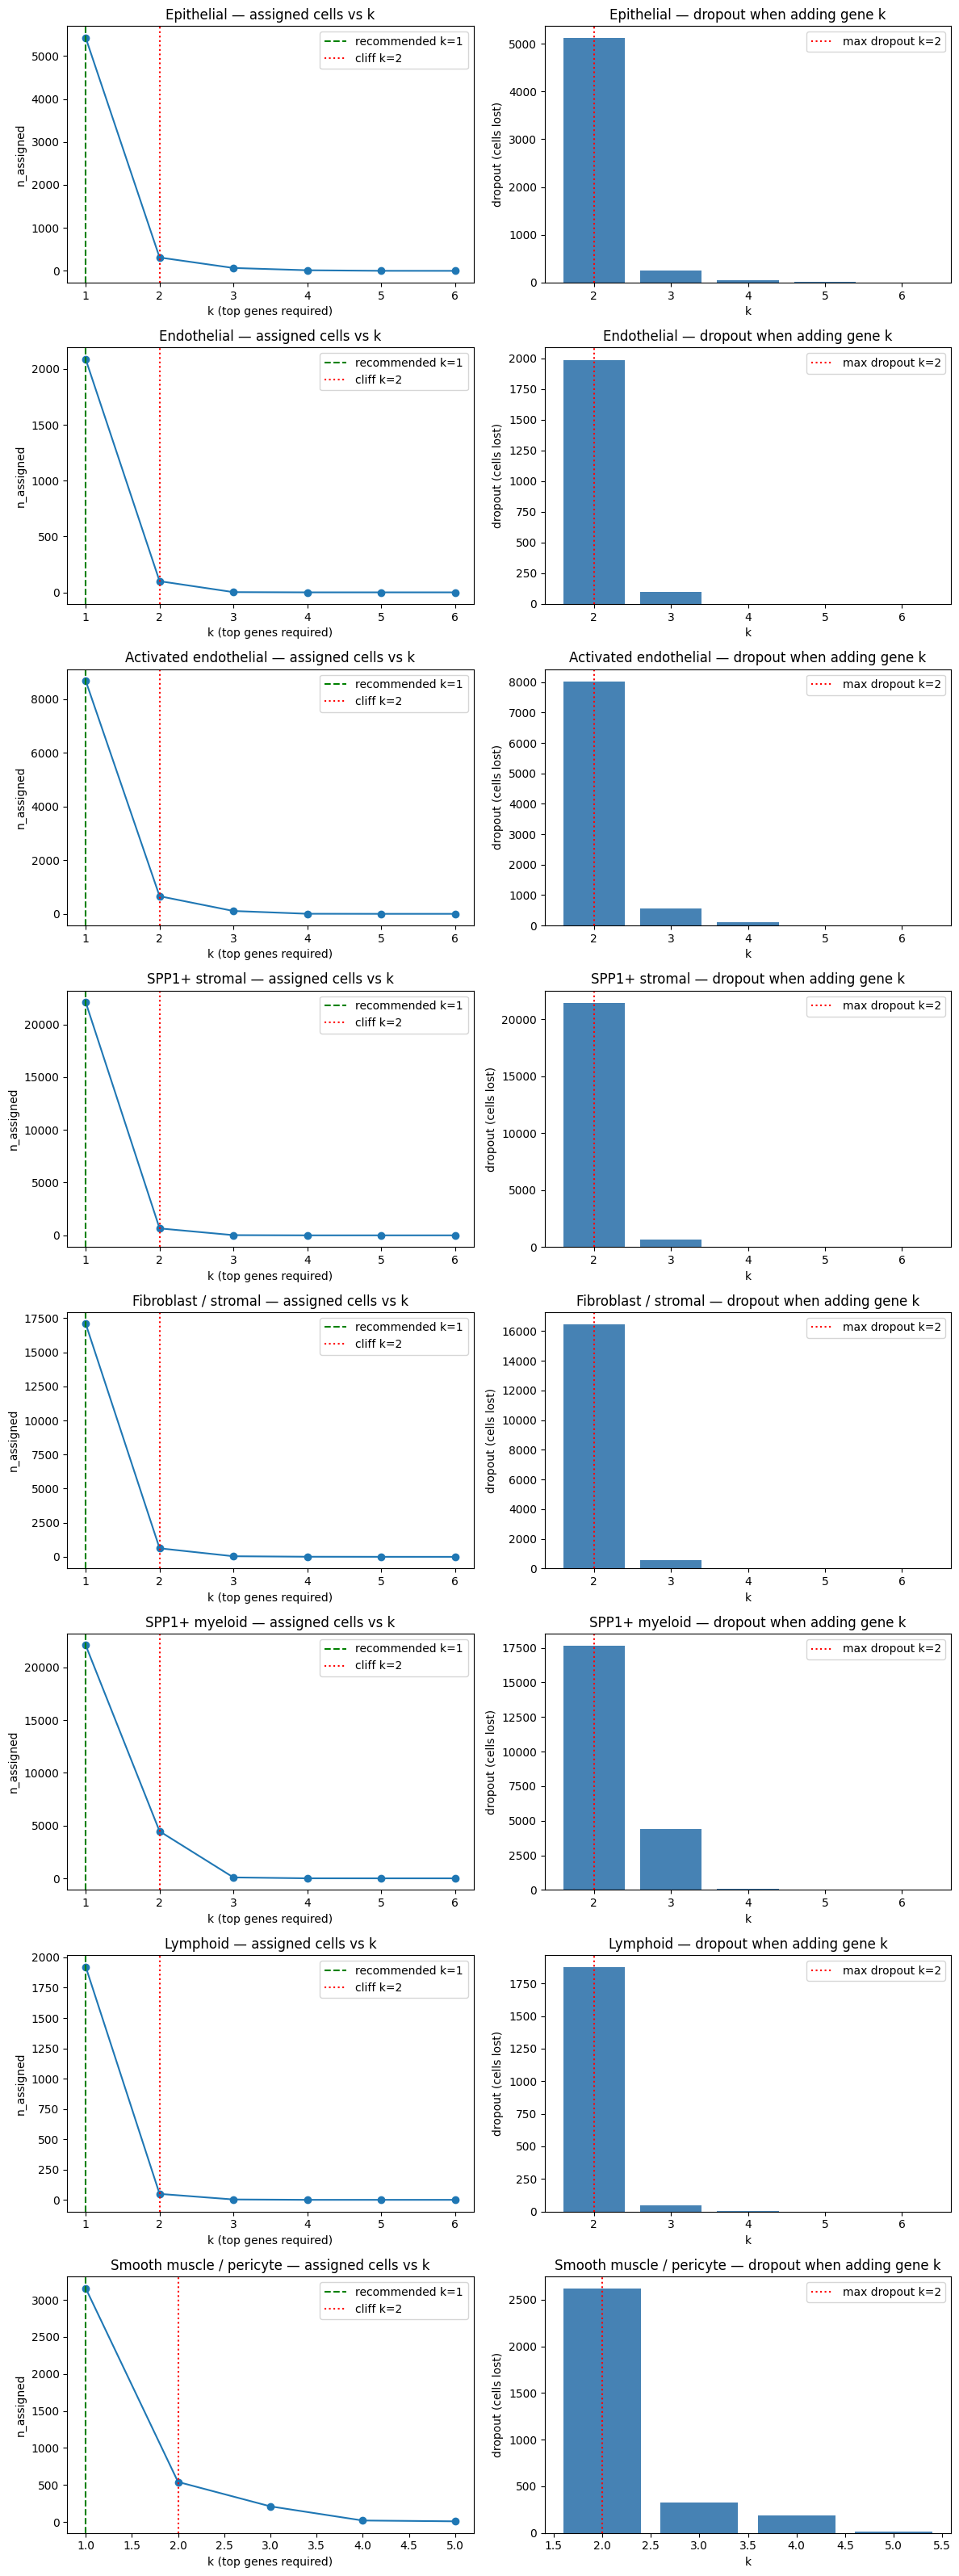

In [8]:
curves = CURATED["curves"]
if curves.empty:
    print("No curation curves to plot.")
else:
    panels = curves["panel"].unique()
    fig, axes = plt.subplots(len(panels), 2, figsize=(12, 4 * len(panels)), squeeze=False)
    for i, panel in enumerate(panels):
        sub = curves[curves["panel"] == panel]
        rec = CURATED["recommendations"][panel]
        k_rec = rec["k_recommended"]
        k_cliff = rec["k_cliff"]

        ax0, ax1 = axes[i]
        ax0.plot(sub["k"], sub["n_assigned"], marker="o")
        ax0.axvline(k_rec, color="green", ls="--", label=f"recommended k={k_rec}")
        if k_cliff >= 2:
            ax0.axvline(k_cliff, color="red", ls=":", label=f"cliff k={k_cliff}")
        ax0.set_title(f"{panel} — assigned cells vs k")
        ax0.set_xlabel("k (top genes required)")
        ax0.set_ylabel("n_assigned")
        ax0.legend()

        cliff = sub.loc[sub["k"] >= 2, ["k", "dropout"]]
        ax1.bar(cliff["k"], cliff["dropout"], color="steelblue")
        if k_cliff >= 2:
            ax1.axvline(k_cliff, color="red", ls=":", label=f"max dropout k={k_cliff}")
        ax1.set_title(f"{panel} — dropout when adding gene k")
        ax1.set_xlabel("k")
        ax1.set_ylabel("dropout (cells lost)")
        ax1.legend()
    plt.tight_layout()
    plt.show()


In [8]:
print(format_curated_yaml_snippet(CURATED))


# Paste under rule_panels in celltyping_config.yaml:
rule_panels:
  Epithelial:
    markers:
      - EPCAM
    min_hits: 1
  Endothelial:
    markers:
      - ENG
    min_hits: 1
  Activated endothelial:
    markers:
      - ICAM1
    min_hits: 1
  SPP1+ stromal:
    markers:
      - SPP1
    min_hits: 1
  Fibroblast / stromal:
    markers:
      - FAP
    min_hits: 1
  SPP1+ myeloid:
    markers:
      - SPP1
    min_hits: 1
  Lymphoid:
    markers:
      - IL7R
    min_hits: 1
  Smooth muscle / pericyte:
    markers:
      - ACTA2
    min_hits: 1


In [9]:
RULE_MARKERS, PANEL_MIN_HITS = resolve_panel_markers(
    adata,
    RULE_PANELS,
    RULE_CFG,
    CURATION_CFG,
)
RULE_MARKER_GENES = flatten_panel_markers(RULE_MARKERS)

print("Resolved markers per panel:")
for label, genes in RULE_MARKERS.items():
    print(f"  {label}: {genes} (min_hits={PANEL_MIN_HITS[label]})")

display(
    panel_detection_summary(
        adata,
        RULE_PANELS,
        top_n=RULE_CFG["top_n_markers"],
        count_threshold=RULE_CFG["count_threshold"],
    )
)


Resolved markers per panel:
  Epithelial: ['EPCAM', 'ALDOB', 'SLC13A3', 'AQP1'] (min_hits=2)
  Endothelial: ['ENG', 'PECAM1', 'EMCN', 'KDR'] (min_hits=2)
  Activated endothelial: ['ICAM1', 'VCAM1', 'SELE', 'INSR'] (min_hits=2)
  SPP1+ stromal: ['SPP1', 'COL1A1', 'SPARC', 'FN1'] (min_hits=2)
  Fibroblast / stromal: ['FAP', 'DCN', 'PDGFRA', 'COL1A1'] (min_hits=2)
  SPP1+ myeloid: ['SPP1', 'APOE', 'C1QA', 'TYROBP'] (min_hits=2)
  Lymphoid: ['IL7R', 'TRAC', 'CD79A', 'CD3D'] (min_hits=2)
  Smooth muscle / pericyte: ['ACTA2', 'TAGLN', 'MYH11', 'PDGFRB'] (min_hits=2)


,panel,gene,detection_rate,rank,selected
0,Epithelial,EPCAM,0.068801,1,True
1,Epithelial,ALDOB,0.051487,2,True
2,Epithelial,SLC13A3,0.044535,3,True
3,Epithelial,AQP1,0.043571,4,True
4,Endothelial,ENG,0.026473,1,True
5,Endothelial,PECAM1,0.021741,2,True
6,Endothelial,EMCN,0.012596,3,True
7,Endothelial,KDR,0.011936,4,True
8,Activated endothelial,ICAM1,0.110191,1,True
9,Activated endothelial,VCAM1,0.033411,2,True


In [14]:
rule_key = OBS_KEYS["cell_type_rule"]

adata.obs[rule_key] = pd.Categorical(
    assign_rule_labels_from_panels(
        adata,
        RULE_MARKERS,
        min_hits=RULE_CFG["min_hits"],
        panel_min_hits=PANEL_MIN_HITS,
        count_threshold=RULE_CFG["count_threshold"],
        ambiguous_label=RULE_CFG["ambiguous_label"],
        unassigned_label=RULE_CFG["unassigned_label"],
    )
)

print("Rule-based labels")
display(adata.obs[rule_key].value_counts())


Rule-based labels


cell_type_rule
Unassigned                  67051
SPP1+ myeloid                3983
Ambiguous                    1637
Fibroblast / stromal         1619
Activated endothelial        1307
Epithelial                   1182
Smooth muscle / pericyte      970
SPP1+ stromal                 724
Endothelial                   208
Lymphoid                      155
Name: count, dtype: int64

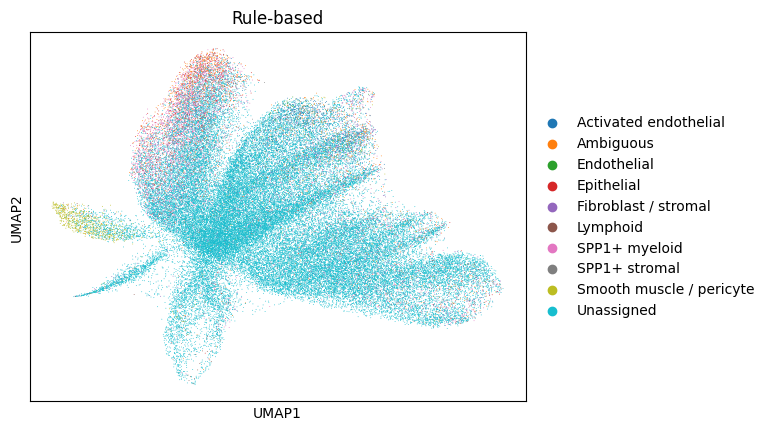

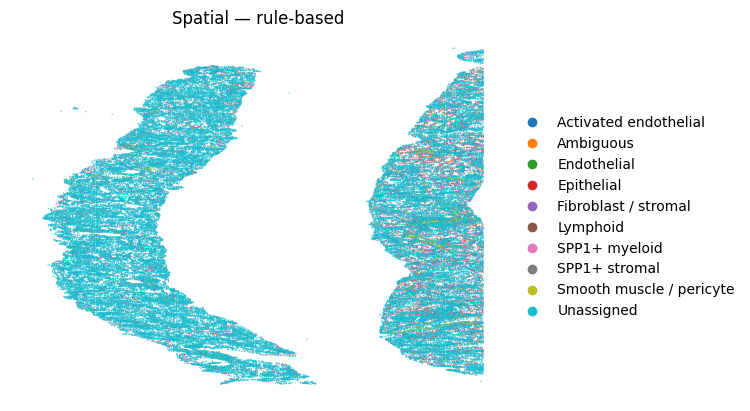

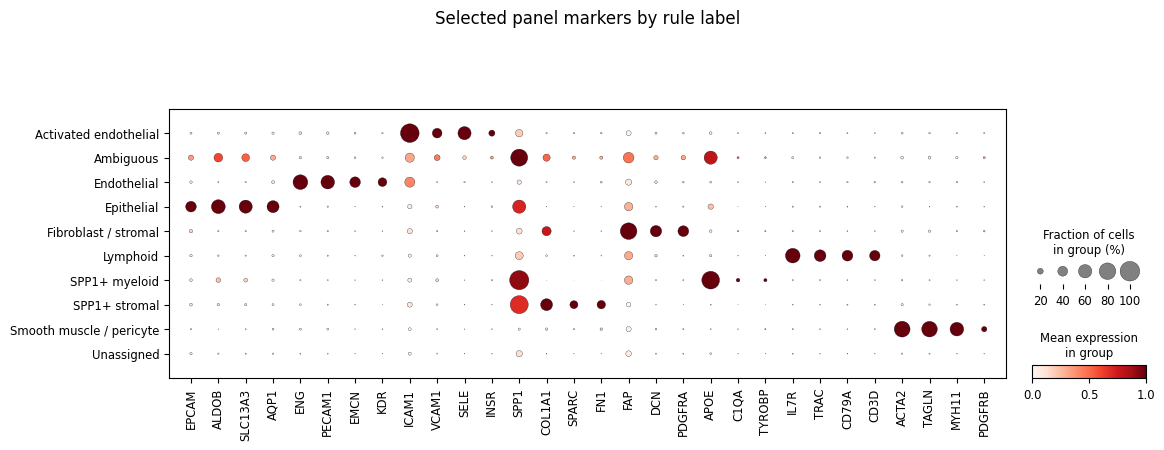

In [11]:
sc.pl.umap(
    adata,
    color=OBS_KEYS["cell_type_rule"],
    title="Rule-based",
)

Utils.SpatialCoord_plot(
    adata,
    variable=OBS_KEYS["cell_type_rule"],
    size=4,
    alpha=0.7,
    title="Spatial — rule-based",
)

if RULE_MARKER_GENES:
    sc.pl.dotplot(
        adata,
        var_names=RULE_MARKER_GENES,
        groupby=OBS_KEYS["cell_type_rule"],
        standard_scale="var",
        title="Selected panel markers by rule label",
    )


## 4. Compare categories: scanpy (i) vs rule-based (ii)

With `comparison.mode: identity`, each scanpy label maps to the **same** rule panel name. **Recapitulate** = rule assigned that label; **rule_abstains** = scanpy expects a lineage but markers did not pass thresholds; **rule_changes** = rule assigned a different lineage.

**Strict match** (`cell_type_scanpy == cell_type_rule`) is the direct fraction of cells with identical strings (including `Unassigned` on both sides when applicable).

**§4b — FDR:** `celltype_fdr` treats one method as ground truth per predicted label; we compare rule→scanpy and scanpy→rule precision (excluding Unassigned/Ambiguous).


In [12]:
scanpy_key = OBS_KEYS["cell_type_scanpy"]
rule_key = OBS_KEYS["cell_type_rule"]

print("Comparison for sample:\n")
print(f"scanpy labels: {sorted(adata.obs[scanpy_key].astype(str).unique())}")
print(f"rule labels: {sorted(adata.obs[rule_key].astype(str).unique())}\n")

print("=== Counts ===")
summary = pd.DataFrame({
    scanpy_key: adata.obs[scanpy_key].value_counts(),
    rule_key: adata.obs[rule_key].value_counts(),
})
display(summary)

print("\n=== Crosstab (scanpy rows × rule cols) ===")
ct = pd.crosstab(adata.obs[scanpy_key], adata.obs[rule_key], margins=True)
display(ct)

print("\n=== Row-normalized crosstab ===")
ct_norm = pd.crosstab(
    adata.obs[scanpy_key],
    adata.obs[rule_key],
    normalize="index",
).round(3)
display(ct_norm)


Comparison for sample:

scanpy labels: ['Activated endothelial', 'Endothelial', 'Epithelial', 'Fibroblast / stromal', 'Lymphoid', 'SPP1+ myeloid', 'SPP1+ stromal', 'Smooth muscle / pericyte', 'Unassigned']
rule labels: ['Activated endothelial', 'Ambiguous', 'Endothelial', 'Epithelial', 'Fibroblast / stromal', 'Lymphoid', 'SPP1+ myeloid', 'SPP1+ stromal', 'Smooth muscle / pericyte', 'Unassigned']

=== Counts ===


,cell_type_scanpy,cell_type_rule
Activated endothelial,7894.0,1307
Ambiguous,NaN,1637
Endothelial,1067.0,208
Epithelial,19331.0,1182
Fibroblast / stromal,6542.0,1619
Lymphoid,3685.0,155
SPP1+ myeloid,7439.0,3983
SPP1+ stromal,16852.0,724
Smooth muscle / pericyte,1515.0,970
Unassigned,14511.0,67051



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule,Activated endothelial,Ambiguous,Endothelial,Epithelial,Fibroblast / stromal,Lymphoid,SPP1+ myeloid,SPP1+ stromal,Smooth muscle / pericyte,Unassigned,All
cell_type_scanpy,,,,,,,,,,,
Activated endothelial,767,167,115,27,124,2,83,64,45,6500,7894
Endothelial,3,4,4,0,46,4,1,1,7,997,1067
Epithelial,86,210,20,179,526,47,623,237,59,17344,19331
Fibroblast / stromal,177,262,39,53,564,29,273,154,102,4889,6542
Lymphoid,25,23,4,29,32,35,113,21,17,3386,3685
SPP1+ myeloid,195,805,9,621,74,13,1803,132,3,3784,7439
SPP1+ stromal,41,131,11,259,201,20,1028,96,22,15043,16852
Smooth muscle / pericyte,1,34,0,1,20,3,3,7,687,759,1515
Unassigned,12,1,6,13,32,2,56,12,28,14349,14511



=== Row-normalized crosstab ===


cell_type_rule,Activated endothelial,Ambiguous,Endothelial,Epithelial,Fibroblast / stromal,Lymphoid,SPP1+ myeloid,SPP1+ stromal,Smooth muscle / pericyte,Unassigned
cell_type_scanpy,,,,,,,,,,
Activated endothelial,0.097,0.021,0.015,0.003,0.016,0.000,0.011,0.008,0.006,0.823
Endothelial,0.003,0.004,0.004,0.000,0.043,0.004,0.001,0.001,0.007,0.934
Epithelial,0.004,0.011,0.001,0.009,0.027,0.002,0.032,0.012,0.003,0.897
Fibroblast / stromal,0.027,0.040,0.006,0.008,0.086,0.004,0.042,0.024,0.016,0.747
Lymphoid,0.007,0.006,0.001,0.008,0.009,0.009,0.031,0.006,0.005,0.919
SPP1+ myeloid,0.026,0.108,0.001,0.083,0.010,0.002,0.242,0.018,0.000,0.509
SPP1+ stromal,0.002,0.008,0.001,0.015,0.012,0.001,0.061,0.006,0.001,0.893
Smooth muscle / pericyte,0.001,0.022,0.000,0.001,0.013,0.002,0.002,0.005,0.453,0.501
Unassigned,0.001,0.000,0.000,0.001,0.002,0.000,0.004,0.001,0.002,0.989


In [13]:
cmp = compare_rule_vs_scanpy(
    adata,
    COMPARISON_CFG,
    scanpy_key=OBS_KEYS["cell_type_scanpy"],
    rule_key=OBS_KEYS["cell_type_rule"],
    rule_cfg=RULE_CFG,
    rule_panel_keys=list(RULE_PANELS.keys()),
)

print(f"Strict match (scanpy == rule): {cmp['pct_strict_match']}% ({cmp['n_strict_match']} / {cmp['n_cells']} cells)")
for msg in cmp.get("alignment_warnings", []):
    print(f"Comparison warning: {msg}")

print(
    "Rule recapitulates mapped scanpy expectation on "
    f"{cmp['pct_recapitulate']}% of cells; "
    f"changes annotation on {cmp['pct_rule_changes']}%; "
    f"abstains on {cmp['pct_rule_abstains']}%."
)
if cmp["n_unmapped_scanpy"]:
    print(f"Unmapped scanpy labels ({cmp['n_unmapped_scanpy']} cells): {cmp['unmapped_scanpy_labels']}")
print(
    f"Among {cmp['n_rule_called']} rule-assigned cells, "
    f"{cmp['pct_recapitulate_given_rule_called']}% recapitulate the mapped expectation."
)

display(
    pd.DataFrame(
        {
            "count": [
                cmp["n_strict_match"],
                cmp["n_recapitulate"],
                cmp["n_rule_changes"],
                cmp["n_rule_abstains"],
                cmp["n_unmapped_scanpy"],
            ]
        },
        index=[
            "strict_match",
            "recapitulate",
            "rule_changes",
            "rule_abstains",
            "unmapped_scanpy",
        ],
    )
)

print("\n=== Per scanpy label (counts) ===")
display(cmp["by_scanpy_counts"])
print("\n=== Per scanpy label (fraction) ===")
display(cmp["by_scanpy_fraction"])

changes = adata.obs[cmp["comparison_obs_key"] == "rule_changes"]
if len(changes):
    print("\n=== Top scanpy × rule among rule_changes ===")
    display(
        pd.crosstab(
            changes[OBS_KEYS["cell_type_scanpy"]],
            changes[OBS_KEYS["cell_type_rule"]],
        )
    )
else:
    print("\nNo rule_changes cells.")


Strict match (scanpy == rule): 23.45% (18484 / 78836 cells)
Rule recapitulates mapped scanpy expectation on 23.45% of cells; changes annotation on 7.63%; abstains on 68.93%.
Among 10148 rule-assigned cells, 40.75% recapitulate the mapped expectation.


,count
strict_match,18484
recapitulate,18485
rule_changes,6013
rule_abstains,54338
unmapped_scanpy,0



=== Per scanpy label (counts) ===


rule_scanpy_comparison,recapitulate,rule_abstains,rule_changes
cell_type_scanpy,,,
Activated endothelial,767,6667,460
Endothelial,4,1001,62
Epithelial,179,17554,1598
Fibroblast / stromal,564,5151,827
Lymphoid,35,3409,241
SPP1+ myeloid,1803,4589,1047
SPP1+ stromal,96,15174,1582
Smooth muscle / pericyte,687,793,35
Unassigned,14350,0,161



=== Per scanpy label (fraction) ===


rule_scanpy_comparison,recapitulate,rule_abstains,rule_changes
cell_type_scanpy,,,
Activated endothelial,0.097,0.845,0.058
Endothelial,0.004,0.938,0.058
Epithelial,0.009,0.908,0.083
Fibroblast / stromal,0.086,0.787,0.126
Lymphoid,0.009,0.925,0.065
SPP1+ myeloid,0.242,0.617,0.141
SPP1+ stromal,0.006,0.900,0.094
Smooth muscle / pericyte,0.453,0.523,0.023
Unassigned,0.989,0.000,0.011


KeyError: False

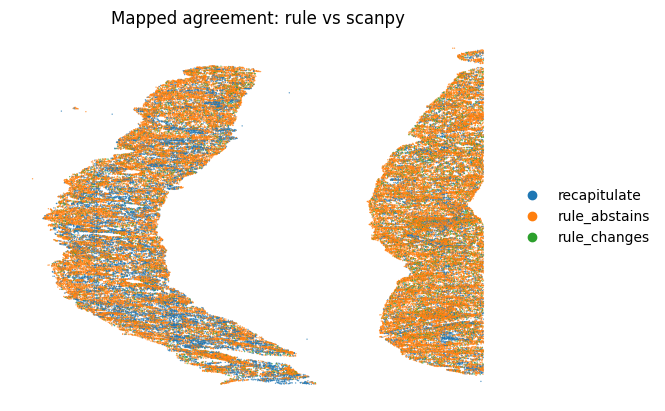

In [14]:
Utils.SpatialCoord_plot(
    adata,
    variable=cmp["comparison_obs_key"],
    size=4,
    alpha=0.7,
    title="Mapped agreement: rule vs scanpy",
)


In [12]:
Utils.custom_barplot(
    adata,
    var_1=OBS_KEYS["cell_type_rule"],
    var_2=OBS_KEYS["cell_type_scanpy"],
    plot_type="bar",
    cluster_bars=False,
    title="Rule labels within scanpy categories",
)


KeyError: "Columns not found in adata.obs: ['cell_type_rule']"

Micro precision (TP / all predicted labels):
  Rule-based (truth = scanpy): 0.407
  Scanpy (truth = rule):       0.064
Macro precision (mean per predicted type):
  Rule-based: 0.328
  Scanpy:     0.113

Higher micro-precision → rule-based agrees more with the other method when it makes a call.


,cell_type,TP,FP,n_predicted,FDR,rule_precision_vs_scanpy
0,Smooth muscle / pericyte,687,283,970,0.291753,0.708247
1,Activated endothelial,767,540,1307,0.413160,0.586840
2,SPP1+ myeloid,1803,2180,3983,0.547326,0.452674
3,Fibroblast / stromal,564,1055,1619,0.651637,0.348363
4,Lymphoid,35,120,155,0.774194,0.225806
5,Epithelial,179,1003,1182,0.848562,0.151438
6,SPP1+ stromal,96,628,724,0.867403,0.132597
7,Endothelial,4,204,208,0.980769,0.019231


,cell_type,TP,FP,n_predicted,FDR,scanpy_precision_vs_rule
0,Smooth muscle / pericyte,687,828,1515,0.546535,0.453465
1,SPP1+ myeloid,1803,5636,7439,0.757629,0.242371
2,Activated endothelial,767,7127,7894,0.902838,0.097162
3,Fibroblast / stromal,564,5978,6542,0.913788,0.086212
4,Lymphoid,35,3650,3685,0.990502,0.009498
5,Epithelial,179,19152,19331,0.990740,0.009260
6,SPP1+ stromal,96,16756,16852,0.994303,0.005697
7,Endothelial,4,1063,1067,0.996251,0.003749


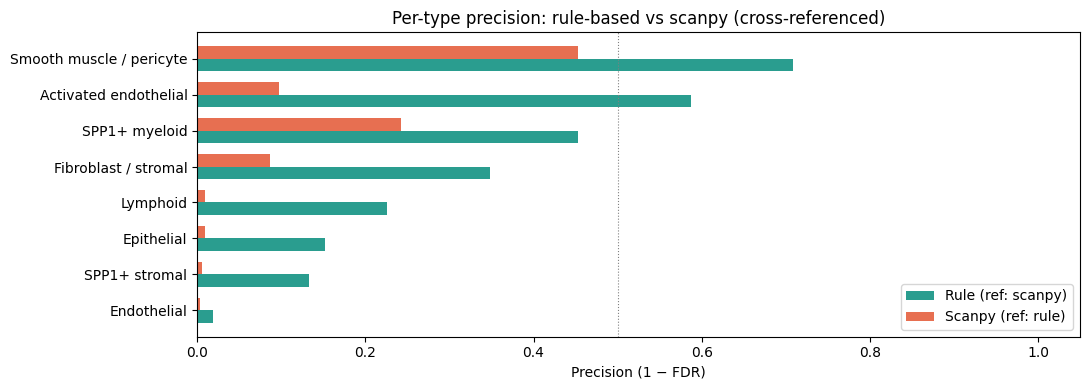

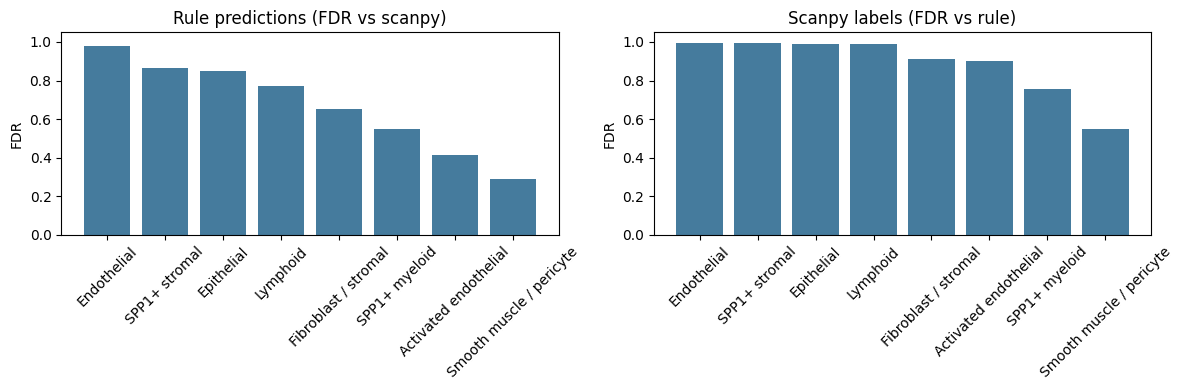

In [15]:
# FDR / precision per label (scanpy as reference for rule calls; symmetric swap for scanpy)
unassigned = list(COMPARISON_CFG.get("unassigned_rule_labels") or [])
if RULE_CFG and not unassigned:
    unassigned = [
        RULE_CFG.get("unassigned_label", "Unassigned"),
        RULE_CFG.get("ambiguous_label", "Ambiguous"),
    ]

fdr_cmp = compare_fdr_rule_vs_scanpy(
    adata.obs,
    OBS_KEYS["cell_type_scanpy"],
    OBS_KEYS["cell_type_rule"],
    unassigned_labels=unassigned,
)

print("Micro precision (TP / all predicted labels):")
print(f"  Rule-based (truth = scanpy): {fdr_cmp['rule_micro_precision']:.3f}")
print(f"  Scanpy (truth = rule):       {fdr_cmp['scanpy_micro_precision']:.3f}")
print("Macro precision (mean per predicted type):")
print(f"  Rule-based: {fdr_cmp['rule_macro_precision']:.3f}")
print(f"  Scanpy:     {fdr_cmp['scanpy_macro_precision']:.3f}")

better = (
    "rule-based"
    if fdr_cmp["rule_micro_precision"] >= fdr_cmp["scanpy_micro_precision"]
    else "scanpy"
)
print(f"\nHigher micro-precision → {better} agrees more with the other method when it makes a call.")

display(
    fdr_cmp["fdr_rule_vs_scanpy"].rename(
        columns={"precision": "rule_precision_vs_scanpy"}
    )
)
display(
    fdr_cmp["fdr_scanpy_vs_rule"].rename(
        columns={"precision": "scanpy_precision_vs_rule"}
    )
)

n_types = max(
    len(fdr_cmp["fdr_rule_vs_scanpy"]),
    len(fdr_cmp["fdr_scanpy_vs_rule"]),
    1,
)
_, fdr_merged = plot_fdr_rule_vs_scanpy(fdr_cmp, figsize=(11, max(4, 0.45 * n_types)))
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax_i, df, title in zip(
    axes,
    [fdr_cmp["fdr_rule_vs_scanpy"], fdr_cmp["fdr_scanpy_vs_rule"]],
    ["Rule predictions (FDR vs scanpy)", "Scanpy labels (FDR vs rule)"],
):
    plot_df = df.sort_values("FDR", ascending=False)
    ax_i.bar(plot_df["cell_type"], plot_df["FDR"], color="#457b9d")
    ax_i.set_ylim(0, 1.05)
    ax_i.set_ylabel("FDR")
    ax_i.set_title(title)
    ax_i.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# adata.write_h5ad(
#     "/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_04/processed_data/scanpy_cluster_cellbased.h5ad"
# )

In [16]:
adata.obs['cell_type_rule']

1_46          Unassigned
2_46          Unassigned
3_46          Unassigned
4_46          Unassigned
5_46          Unassigned
               ...      
699_172        Ambiguous
713_172    SPP1+ myeloid
740_172       Unassigned
747_172       Unassigned
45_174        Unassigned
Name: cell_type_rule, Length: 78836, dtype: category
Categories (10, object): ['Activated endothelial', 'Ambiguous', 'Endothelial', 'Epithelial', ..., 'SPP1+ myeloid', 'SPP1+ stromal', 'Smooth muscle / pericyte', 'Unassigned']